In [1]:
import sys
from pathlib import Path

# プロジェクトのルートディレクトリをパスに追加
project_root = Path.cwd().parent.parent  # notebooks/assistments_2009_2010/ から2階層上がる
sys.path.insert(0, str(project_root))

print(f"Added to path: {project_root}")

import torch
import numpy as np
import pandas as pd
from typing import Dict, Any
import os
import matplotlib.pyplot as plt
import seaborn as sns

# 作業ディレクトリをプロジェクトルートに変更（この行を追加）
os.chdir(project_root)
print(f"Changed working directory to: {os.getcwd()}")

from src.utils.config_synthetic import load_yaml, generate_grid
from src.utils.seed import set_seed, derive_seed
from src.utils.device import get_device
from src.methods.registry import build_method
from src.datasets.generate_assistments_2009_2010_data import generate_data
from src.datasets.factory import build_dataset, build_test_dataset
from src.evaluation.evaluator import evaluate_testdata, evaluate_distribution


base_cfg = load_yaml("configs/Assistments_2009_2010/base.yaml")
train_cfg = load_yaml("configs/Assistments_2009_2010/train.yaml")
# ... 以下続く

device = get_device()
seed = 0  # 固定シード

Added to path: /Users/nagairyousuke/Documents/kashima_lab/master_paper
Changed working directory to: /Users/nagairyousuke/Documents/kashima_lab/master_paper


/Users/nagairyousuke/Documents/kashima_lab/master_paper/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: cpu


Dataset: s47_s49_s58_s67_s70_s74_s277_s278_s279_s280
Path: data/processed/assistments_2009_2010/first_all_dina_estimation/s47_s49_s58_s67_s70_s74_s277_s278_s279_s280
学習者数: 111
スキル数: 10
Current shape: (111, 10)
Future shape: (111, 10)
スキル名: ['skill_47', 'skill_49', 'skill_58', 'skill_67', 'skill_70', 'skill_74', 'skill_277', 'skill_278', 'skill_279', 'skill_280']

各スキルの習得率:
  skill_47: Current=90.09%, Future=92.79%
  skill_49: Current=82.88%, Future=90.09%
  skill_58: Current=54.05%, Future=77.48%
  skill_67: Current=85.59%, Future=97.30%
  skill_70: Current=78.38%, Future=83.78%
  skill_74: Current=29.73%, Future=32.43%
  skill_277: Current=81.98%, Future=88.29%
  skill_278: Current=47.75%, Future=67.57%
  skill_279: Current=94.59%, Future=99.10%
  skill_280: Current=24.32%, Future=39.64%



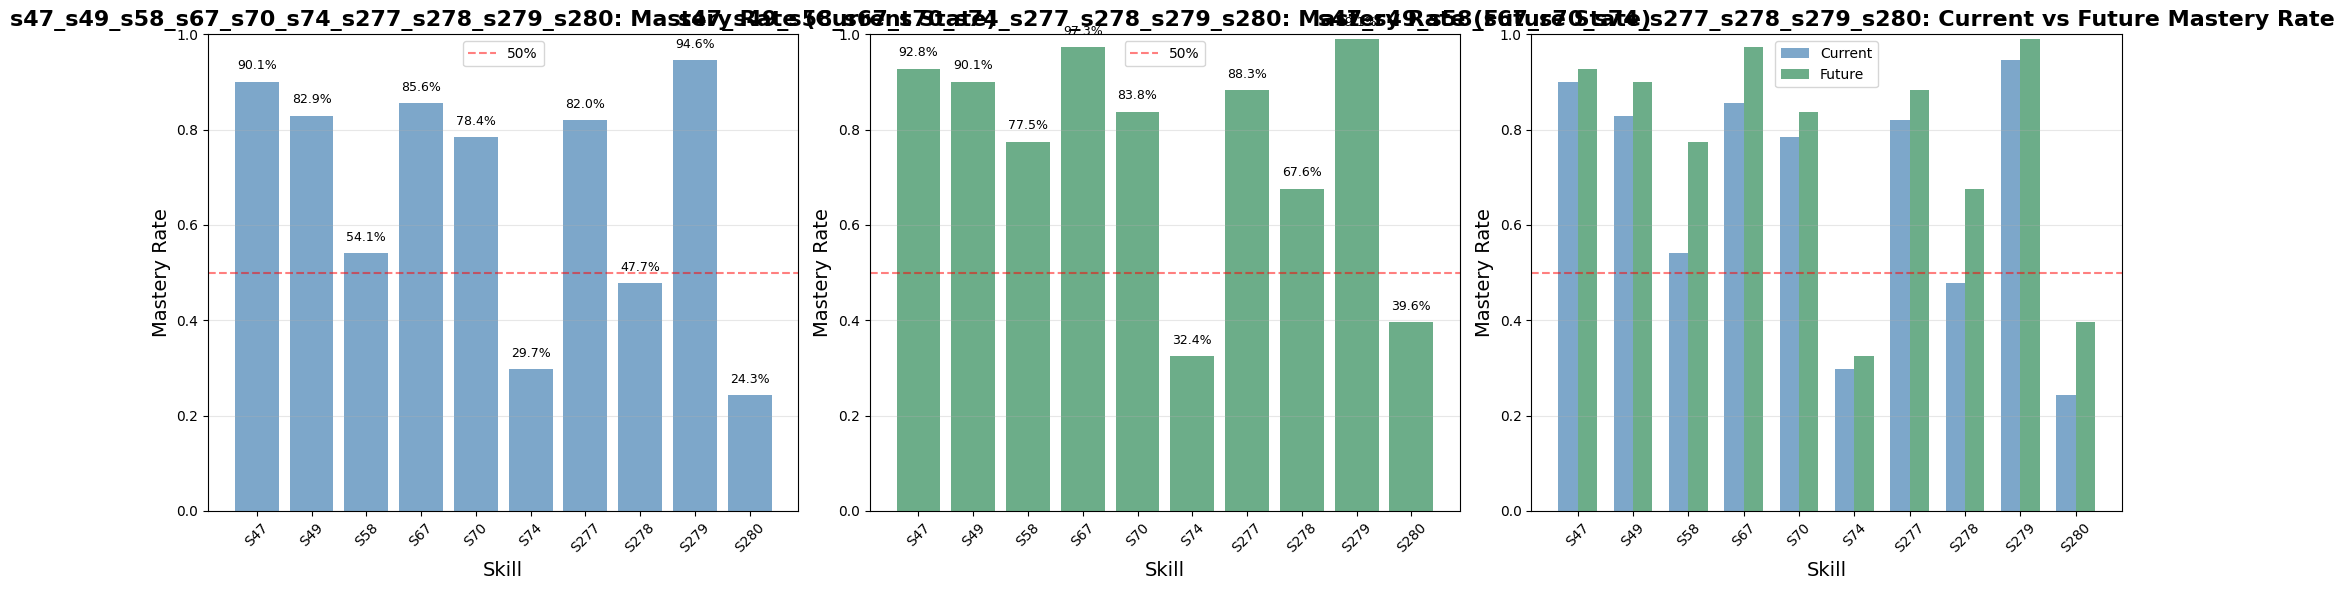


【習得率の統計情報】
Current State:
  平均: 66.94%
  最小: 24.32% (S280)
  最大: 94.59% (S279)
  標準偏差: 0.2448

Future State:
  平均: 76.85%
  最小: 32.43% (S74)
  最大: 99.10% (S279)
  標準偏差: 0.2228

習得率の変化 (Future - Current):
  平均増加: 9.91%
  最大増加: 23.42% (S58)
  最小増加: 2.70% (S47)

習得率の変化が大きいスキル（上位3つ）:
  S58: 54.05% → 77.48% (+23.42%)
  S278: 47.75% → 67.57% (+19.82%)
  S280: 24.32% → 39.64% (+15.32%)



In [2]:
import os

# 各データセットのalpha_current.csvとalpha_future.csvを読み込んで習得率を計算
for dataset_cfg in base_cfg["dataset"]:
    dataset_name = dataset_cfg["name"]
    dataset_path = dataset_cfg["id"]
    n_skills = dataset_cfg["n_skills"]
    
    # ファイルパスを構築
    current_path = os.path.join(dataset_path, "alpha_current.csv")
    future_path = os.path.join(dataset_path, "alpha_future.csv")
    
    print("="*80)
    print(f"Dataset: {dataset_name}")
    print(f"Path: {dataset_path}")
    print("="*80)
    
    # CSVファイルを読み込み
    if os.path.exists(current_path) and os.path.exists(future_path):
        # ヘッダー行をスキップして読み込み、最初の列（user_id）も除外
        alpha_current_df = pd.read_csv(current_path, header=0, index_col=0)
        alpha_future_df = pd.read_csv(future_path, header=0, index_col=0)
        
        alpha_current = alpha_current_df.values.astype(float)
        # alpha_futureはalpha_currentとの論理和（OR演算）
        alpha_future_raw = alpha_future_df.values.astype(float)
        alpha_future = np.logical_or(alpha_current, alpha_future_raw).astype(float)
        
        n_learners = alpha_current.shape[0]
        
        print(f"学習者数: {n_learners}")
        print(f"スキル数: {n_skills}")
        print(f"Current shape: {alpha_current.shape}")
        print(f"Future shape: {alpha_future.shape}")
        print(f"スキル名: {list(alpha_current_df.columns)}")
        print()
        
        # 各スキルの習得率を計算（習得している学習者の割合）
        current_mastery_rate = alpha_current.mean(axis=0)  # (n_skills,)
        future_mastery_rate = alpha_future.mean(axis=0)    # (n_skills,)
        
        print("各スキルの習得率:")
        for i, (skill_name, cur_rate, fut_rate) in enumerate(zip(alpha_current_df.columns, 
                                                                   current_mastery_rate, 
                                                                   future_mastery_rate)):
            print(f"  {skill_name}: Current={cur_rate:.2%}, Future={fut_rate:.2%}")
        print()
        
        # 可視化
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))
        
        # スキル名を短縮（skill_XX -> XX）
        skill_labels = [col.replace('skill_', 'S') for col in alpha_current_df.columns]
        
        # 1. Current Stateの習得率
        ax1 = axes[0]
        bars1 = ax1.bar(range(n_skills), current_mastery_rate, color='steelblue', alpha=0.7)
        ax1.set_xlabel('Skill', fontsize=14)
        ax1.set_ylabel('Mastery Rate', fontsize=14)
        ax1.set_title(f'{dataset_name}: Mastery Rate (Current State)', fontsize=16, fontweight='bold')
        ax1.set_xticks(range(n_skills))
        ax1.set_xticklabels(skill_labels, rotation=45)
        ax1.set_ylim(0, 1.0)
        ax1.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
        ax1.grid(axis='y', alpha=0.3)
        ax1.legend()
        
        # 各バーの上に数値を表示
        for i, (bar, rate) in enumerate(zip(bars1, current_mastery_rate)):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
        
        # 2. Future Stateの習得率
        ax2 = axes[1]
        bars2 = ax2.bar(range(n_skills), future_mastery_rate, color='seagreen', alpha=0.7)
        ax2.set_xlabel('Skill', fontsize=14)
        ax2.set_ylabel('Mastery Rate', fontsize=14)
        ax2.set_title(f'{dataset_name}: Mastery Rate (Future State)', fontsize=16, fontweight='bold')
        ax2.set_xticks(range(n_skills))
        ax2.set_xticklabels(skill_labels, rotation=45)
        ax2.set_ylim(0, 1.0)
        ax2.axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='50%')
        ax2.grid(axis='y', alpha=0.3)
        ax2.legend()
        
        # 各バーの上に数値を表示
        for i, (bar, rate) in enumerate(zip(bars2, future_mastery_rate)):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{rate:.1%}', ha='center', va='bottom', fontsize=9)
        
        # 3. Current vs Future の比較
        ax3 = axes[2]
        x = np.arange(n_skills)
        width = 0.35
        bars3_cur = ax3.bar(x - width/2, current_mastery_rate, width, label='Current', color='steelblue', alpha=0.7)
        bars3_fut = ax3.bar(x + width/2, future_mastery_rate, width, label='Future', color='seagreen', alpha=0.7)
        
        ax3.set_xlabel('Skill', fontsize=14)
        ax3.set_ylabel('Mastery Rate', fontsize=14)
        ax3.set_title(f'{dataset_name}: Current vs Future Mastery Rate', fontsize=16, fontweight='bold')
        ax3.set_xticks(x)
        ax3.set_xticklabels(skill_labels, rotation=45)
        ax3.set_ylim(0, 1.0)
        ax3.axhline(y=0.5, color='red', linestyle='--', alpha=0.5)
        ax3.legend()
        ax3.grid(axis='y', alpha=0.3)
        
        plt.tight_layout()
        plt.show()
        
        # 習得率の統計情報
        print("\n【習得率の統計情報】")
        print(f"Current State:")
        print(f"  平均: {current_mastery_rate.mean():.2%}")
        print(f"  最小: {current_mastery_rate.min():.2%} ({skill_labels[current_mastery_rate.argmin()]})")
        print(f"  最大: {current_mastery_rate.max():.2%} ({skill_labels[current_mastery_rate.argmax()]})")
        print(f"  標準偏差: {current_mastery_rate.std():.4f}")
        print()
        print(f"Future State:")
        print(f"  平均: {future_mastery_rate.mean():.2%}")
        print(f"  最小: {future_mastery_rate.min():.2%} ({skill_labels[future_mastery_rate.argmin()]})")
        print(f"  最大: {future_mastery_rate.max():.2%} ({skill_labels[future_mastery_rate.argmax()]})")
        print(f"  標準偏差: {future_mastery_rate.std():.4f}")
        print()
        
        # 習得率の変化（増加率）
        mastery_gain = future_mastery_rate - current_mastery_rate
        print(f"習得率の変化 (Future - Current):")
        print(f"  平均増加: {mastery_gain.mean():.2%}")
        print(f"  最大増加: {mastery_gain.max():.2%} ({skill_labels[mastery_gain.argmax()]})")
        print(f"  最小増加: {mastery_gain.min():.2%} ({skill_labels[mastery_gain.argmin()]})")
        
        # 変化が大きいスキルをリストアップ
        print(f"\n習得率の変化が大きいスキル（上位3つ）:")
        top_indices = np.argsort(mastery_gain)[::-1][:3]
        for idx in top_indices:
            print(f"  {skill_labels[idx]}: {current_mastery_rate[idx]:.2%} → {future_mastery_rate[idx]:.2%} (+{mastery_gain[idx]:.2%})")
        print()
        
    else:
        print(f"警告: ファイルが見つかりません")
        print(f"  Current: {current_path} - {'存在' if os.path.exists(current_path) else '不在'}")
        print(f"  Future: {future_path} - {'存在' if os.path.exists(future_path) else '不在'}")
        print()

In [3]:

# モデルと結果を保存する辞書
saved_methods = {}
saved_predictions = {}
saved_test_data = {}
saved_train_data = {}

for dataset_cfg in base_cfg["dataset"]:
    records = []  # データセットごとに初期化
    pre_current_dataset, pre_future_dataset = generate_data(data_dir=dataset_cfg["id"], n_skills=dataset_cfg["n_skills"])
    split_ratio = base_cfg["split_ratio"]
    print(pre_current_dataset.shape, pre_future_dataset.shape)

    print(f"=== Dataset: {dataset_cfg['name']} ===")
    print(f"Number of students: {len(pre_current_dataset)}")
    print(f"Number of skills: {dataset_cfg['n_skills']}")
    # print(pre_current_dataset)
    # print(pre_future_dataset)

    # seedを使ってシャッフル
    n_samples = len(pre_current_dataset)
    rng = np.random.RandomState(seed)
    indices = rng.permutation(n_samples)
    
    # シャッフルされたデータ
    shuffled_current = pre_current_dataset[indices]
    shuffled_future = pre_future_dataset[indices]
    
    # train/test分割
    split_idx = int(n_samples * split_ratio)
    current_dataset = shuffled_current[:split_idx]
    future_dataset = shuffled_future[:split_idx]
    test_future = shuffled_future[split_idx:]
    
    test_data = {
        "X_test": torch.from_numpy(test_future[:, 0, :]).to(device),
        "y_test": torch.from_numpy(test_future[:, 1, :]).to(device),
    }
    
    # データセット名でテストデータを保存
    dataset_name = dataset_cfg['name']
    saved_test_data[dataset_name] = test_data
    saved_methods[dataset_name] = {}
    saved_predictions[dataset_name] = {}
    saved_train_data[dataset_name] = {}
    
    for method_cfg in base_cfg["methods"]:
        method_seed = derive_seed(seed, method_cfg["id"])  # methodごとに分ける
        set_seed(method_seed)

        # exp_cfgを作成（proposedメソッドの場合のみ必要）
        if method_cfg["id"] in ["proposed", "full_information"]:
            exp_cfg = {
                "n_students": len(current_dataset),
                "n_skills": dataset_cfg["n_skills"],
                "dataset_name": dataset_cfg["name"],
            }
        else:
            exp_cfg = None

        # モデル定義
        method = build_method(
            method_cfg=method_cfg,
            device=device,
            seed=method_seed,
            exp_cfg=exp_cfg,
            training_cfg=train_cfg if exp_cfg is not None else None,
            save=False,
        )

        # モデル学習
        train_data = build_dataset(
            method_cfg=method_cfg,
            current_dataset=current_dataset,
            future_dataset=future_dataset,
            device=device,
        )
        method.fit(train_data)

        # テストデータ予測
        out = method.predict(test_data)

        # 評価
        test_metrics = base_cfg["evaluation"]["test_metrics"]

        scores_testdata = evaluate_testdata(
            pred=out,
            input=test_data["X_test"].cpu().numpy(),
            target=test_data["y_test"].cpu().numpy(),
            metrics=test_metrics,
        )
        record = {
            "seed": seed,
            "method": method_cfg["id"],
        }
        for k, v in scores_testdata.items():
            record[k] = v
        records.append(record)
        
        # モデル、予測結果、訓練データを保存
        method_name = method_cfg["id"]
        saved_methods[dataset_name][method_name] = method
        saved_predictions[dataset_name][method_name] = out
        saved_train_data[dataset_name][method_name] = train_data
        
        print(f"  Saved {method_name}: ACC={record.get('acc', 'N/A'):.4f}")

print("\n" + "="*80)
print("保存されたモデル:")
for dataset_name, methods in saved_methods.items():
    print(f"\n{dataset_name}:")
    for method_name in methods.keys():
        print(f"  - {method_name}")

データ読み込み: alpha_current.csv, alpha_future.csv
データセット生成完了:
  学生数: 111
  スキル数: 10
  前半平均習得率: 66.94%
  後半平均習得率（元）: 74.68%
  後半平均習得率（新）: 76.85%

スキル状態の変化:
  習得: 110件 (9.91%)
  ⚠️  喪失: 24件 (2.16%) → 論理和で修正済み
  維持: 719件 (64.77%)
  未習得: 257件 (23.15%)

学生ごとの習得スキル数:
  前半平均: 6.69 / 10
  後半平均（元）: 7.47 / 10
  後半平均（新）: 7.68 / 10
  平均純増: 0.99
  平均純増（元）: 0.77
(111, 2, 10) (111, 2, 10)
=== Dataset: s47_s49_s58_s67_s70_s74_s277_s278_s279_s280 ===
Number of students: 111
Number of skills: 10
[Skip] Found existing model file: outputs/assistments_2009_2010/first_all_dina_estimation/models_L1_0.001/77_10_L1_0.001_proposed_3426455387.pt
  Saved proposed: ACC=0.9559
[Skip] Found existing model file: outputs/assistments_2009_2010/first_all_dina_estimation/models_L1_0.001/77_10_L1_0.001_full_information_2569488773.pt
  Saved full_information: ACC=0.9559
  Saved popularity: ACC=0.8873
  Saved simple_markov: ACC=0.8725
  Saved random: ACC=0.7108


  0%|          | 5/1000000 [00:00<4:25:30, 62.77it/s]

  Saved bayesian_network: ACC=0.9412

保存されたモデル:

s47_s49_s58_s67_s70_s74_s277_s278_s279_s280:
  - proposed
  - full_information
  - popularity
  - simple_markov
  - random
  - bayesian_network



Dataset: S47_S49_S58_S67_S70_S74_S277_S278_S279_S280

【評価結果】


,Method,ACC,SPA,ACE,MSE
0,proposed,0.955882,0.849648,0.240534,0.030384
1,full_information,0.955882,0.864504,0.217824,0.027859
5,bayesian_network,0.941176,0.826067,0.274744,0.034595
3,simple_markov,0.911765,0.854085,0.841924,0.037630
2,popularity,0.897059,0.782746,0.340223,0.043331
4,random,0.750000,0.760392,0.397374,0.041275


データ読み込み: alpha_current.csv, alpha_future.csv
データセット生成完了:
  学生数: 111
  スキル数: 10
  前半平均習得率: 66.94%
  後半平均習得率（元）: 74.68%
  後半平均習得率（新）: 76.85%

スキル状態の変化:
  習得: 110件 (9.91%)
  ⚠️  喪失: 24件 (2.16%) → 論理和で修正済み
  維持: 719件 (64.77%)
  未習得: 257件 (23.15%)

学生ごとの習得スキル数:
  前半平均: 6.69 / 10
  後半平均（元）: 7.47 / 10
  後半平均（新）: 7.68 / 10
  平均純増: 0.99
  平均純増（元）: 0.77

【Future Datasetの概要】
Current state (前半): shape=(111, 10)
Future state (後半): shape=(111, 10)


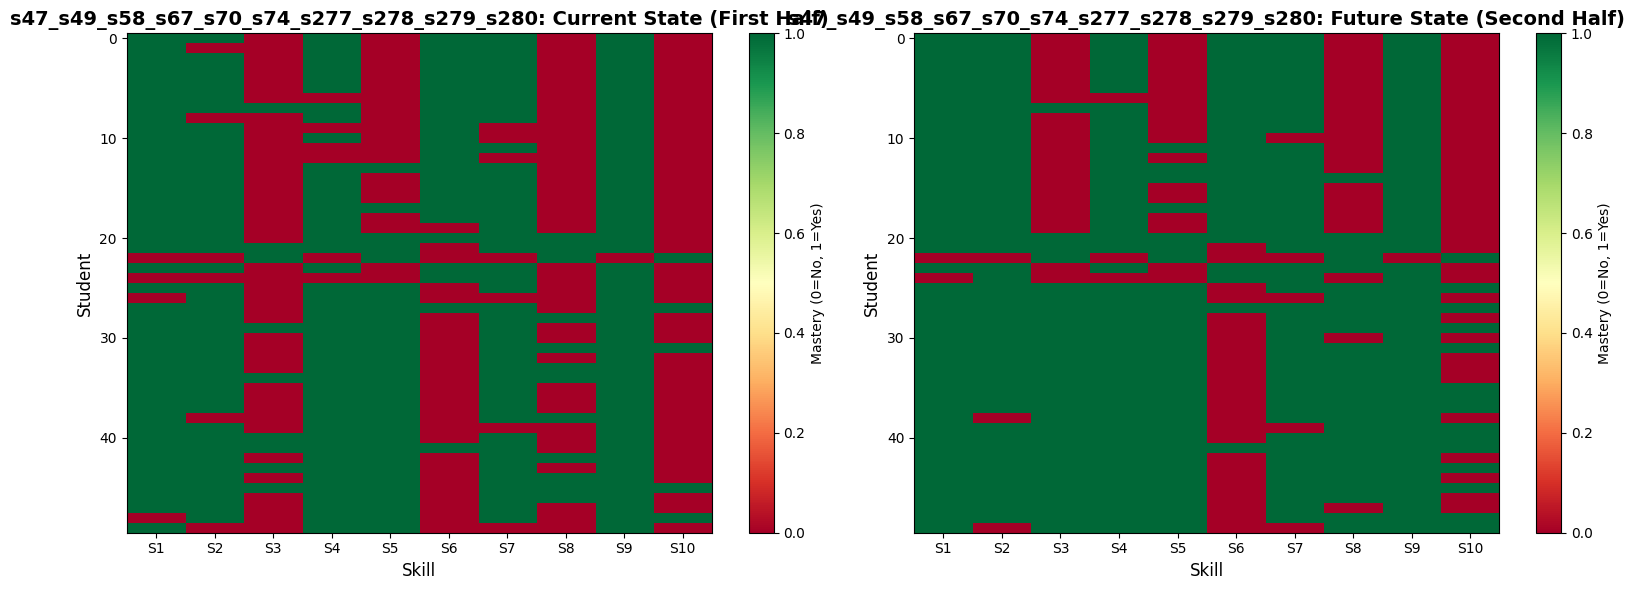


【テストデータとモデル出力の定性的比較】
テストサンプル数: 34

サンプル 1/10

現在の状態 (Current):  [1. 0. 0. 1. 1. 0. 0. 0. 1. 0.]
正解の将来 (True):     [1. 0. 1. 1. 1. 0. 0. 1. 1. 1.]
獲得スキル数: 3 スキル

【各手法の予測】

proposed            : [1.         0.81128216 0.5185392  1.         1.         0.14927575
 1.         0.32792637 1.         0.19297644]
                      予測獲得数: 3.00, 誤差: 3.92
                      スキル別一致: [1 0 1 1 1 1 0 0 1 0], ACC: 60.00%

full_information    : [1.         1.         0.5625173  1.         1.         0.11902864
 0.73508036 0.40436387 1.         0.1790098 ]
                      予測獲得数: 3.00, 誤差: 3.71
                      スキル別一致: [1 0 1 1 1 1 0 0 1 0], ACC: 60.00%

popularity          : [1.         0.7721519  0.46835443 1.         1.         0.36708861
 0.83544304 0.36708861 1.         0.18987342]
                      予測獲得数: 3.00, 誤差: 3.95
                      スキル別一致: [1 0 0 1 1 1 0 0 1 0], ACC: 50.00%

simple_markov       : [1.   0.25 1.   1.   1.   0.25 1.   0.25 1.   0.25]
                   

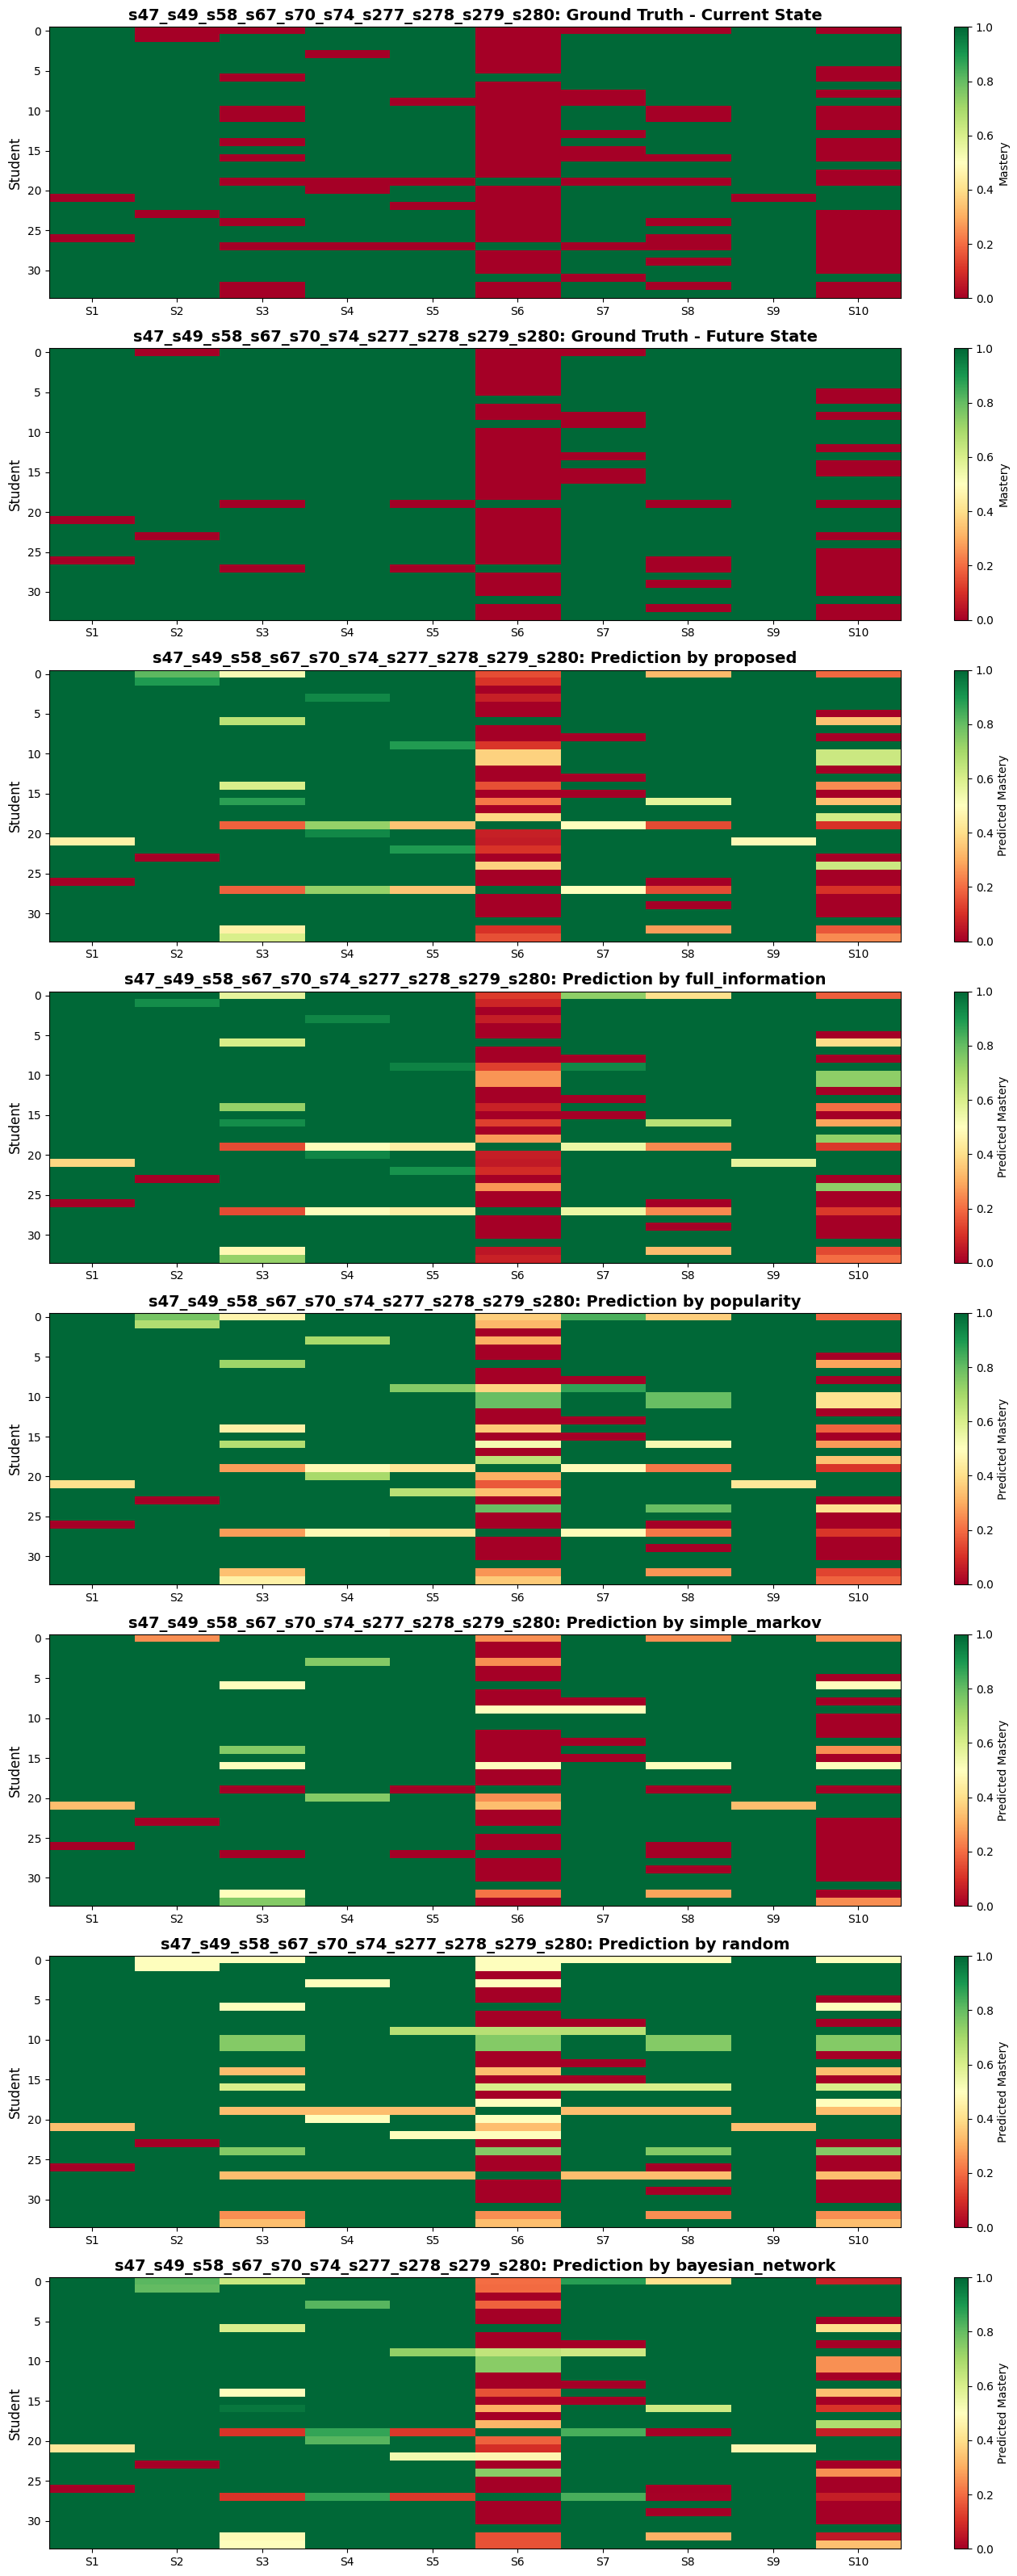


【誤差分析】


/var/folders/zg/773ptkr55z99zw26dvy19_v00000gn/T/ipykernel_47149/1571048338.py:179: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax2.boxplot(error_data, labels=labels, patch_artist=True, showmeans=True)


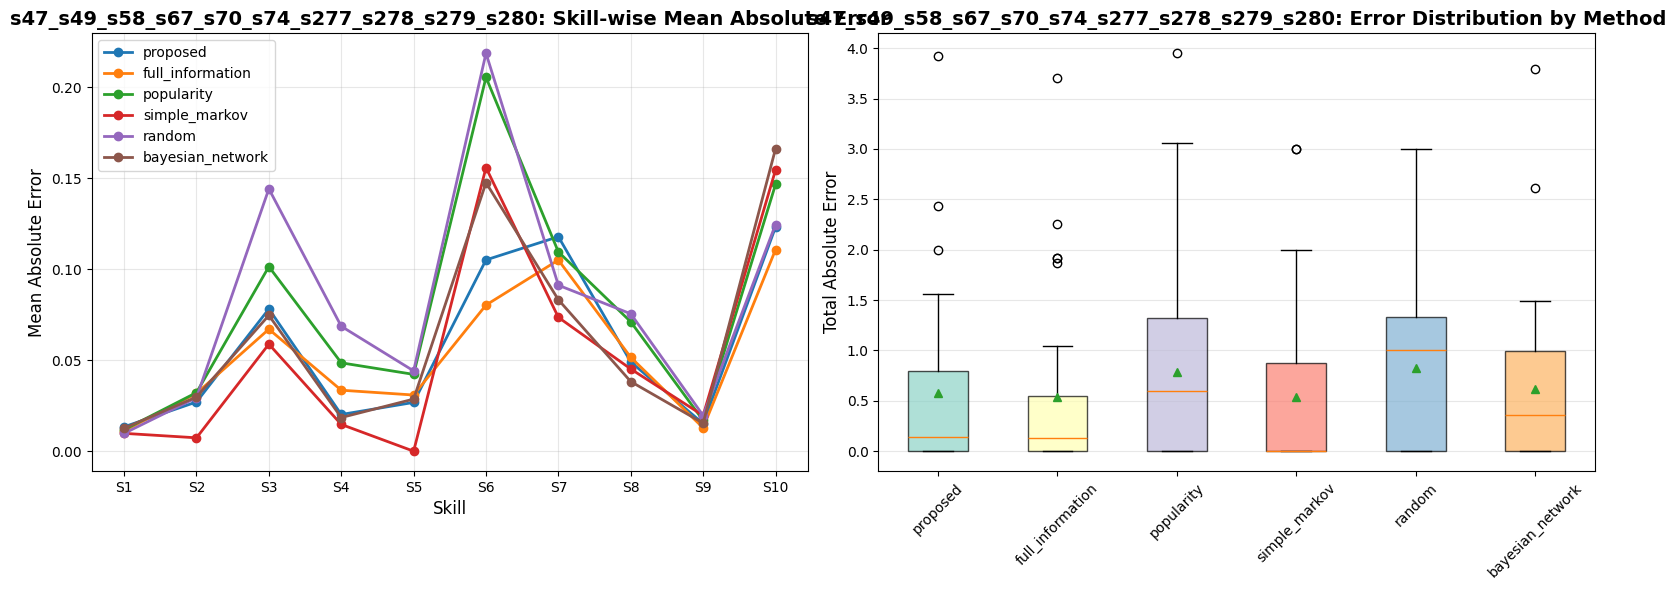


【Proposedモデルのパラメータ】

fc.weight:
  Shape: torch.Size([10, 10])
  Mean: 0.019519
  Std: 0.150496
  Min: -0.547181
  Max: 0.429948
  L1 norm: 8.663608
  Values:
tensor([[ 1.4083e-01,  2.2441e-01,  2.1837e-01,  4.6920e-03,  7.2127e-03,
          1.9845e-01,  1.5600e-03,  6.6248e-04,  1.2240e-01,  2.4096e-03],
        [-3.1813e-03,  1.6473e-01,  3.2973e-02,  3.9416e-04,  1.4813e-03,
         -9.1450e-03, -8.4565e-04,  2.2431e-03,  9.8515e-04,  1.7729e-03],
        [-4.9766e-03, -4.2604e-02, -4.3457e-02, -2.0751e-02, -2.0157e-02,
         -2.3348e-01, -2.2531e-03, -1.2186e-01, -8.7599e-03, -7.4942e-04],
        [ 8.9330e-03,  3.5033e-01,  3.2615e-01,  5.2128e-02,  1.0506e-02,
          2.8870e-01,  2.4390e-02,  1.4589e-02,  3.4033e-01,  9.3501e-02],
        [ 2.5479e-03, -1.3208e-04,  1.0809e-02,  4.0360e-03,  5.3967e-03,
          7.3438e-03,  2.3894e-02,  4.3618e-04,  2.9140e-01,  1.0960e-02],
        [-1.0978e-01, -1.6770e-01, -4.2755e-02, -5.4718e-01, -1.8518e-01,
         -2.0136e-02, 

In [4]:
# 結果の表示と可視化
for dataset_name in saved_methods.keys():
    print("\n" + "="*80)
    print(f"Dataset: {dataset_name.upper()}")
    print("="*80)
    
    # === 1. 各手法の評価結果 ===
    print("\n【評価結果】")
    results_summary = []
    for method_name, prediction in saved_predictions[dataset_name].items():
        test_data = saved_test_data[dataset_name]
        
        # 評価指標を計算
        scores = evaluate_testdata(
            pred=prediction,
            input=test_data["X_test"].cpu().numpy(),
            target=test_data["y_test"].cpu().numpy(),
            metrics=['acc', 'spa', 'ace', 'mse']
        )
        
        results_summary.append({
            'Method': method_name,
            'ACC': scores['acc'],
            'SPA': scores['spa'],
            'ACE': scores['ace'],
            'MSE': scores['mse']
        })
    
    df_results = pd.DataFrame(results_summary)
    display(df_results.sort_values('ACC', ascending=False))
    
    # === 2. Future Datasetの可視化 ===
    # データを再取得
    dataset_cfg = [d for d in base_cfg["dataset"] if d['name'] == dataset_name][0]
    pre_current_dataset, pre_future_dataset = generate_data(
        data_dir=dataset_cfg["id"], 
        n_skills=dataset_cfg["n_skills"]
    )
    
    current_skills = pre_future_dataset[:, 0, :]  # 現在の状態
    future_skills = pre_future_dataset[:, 1, :]   # 将来の状態
    n_skills = dataset_cfg["n_skills"]
    
    print("\n【Future Datasetの概要】")
    print(f"Current state (前半): shape={current_skills.shape}")
    print(f"Future state (後半): shape={future_skills.shape}")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 現在の状態のヒートマップ
    ax1 = axes[0]
    sample_size = min(50, len(current_skills))
    im1 = ax1.imshow(current_skills[:sample_size], cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Student', fontsize=12)
    ax1.set_title(f'{dataset_name}: Current State (First Half)', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_skills))
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im1, ax=ax1, label='Mastery (0=No, 1=Yes)')
    
    # 将来の状態のヒートマップ
    ax2 = axes[1]
    im2 = ax2.imshow(future_skills[:sample_size], cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax2.set_xlabel('Skill', fontsize=12)
    ax2.set_ylabel('Student', fontsize=12)
    ax2.set_title(f'{dataset_name}: Future State (Second Half)', fontsize=14, fontweight='bold')
    ax2.set_xticks(range(n_skills))
    ax2.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im2, ax=ax2, label='Mastery (0=No, 1=Yes)')
    
    plt.tight_layout()
    plt.show()
    
    # === 3. テストデータと各モデルの出力の定性的比較 ===
    print("\n【テストデータとモデル出力の定性的比較】")
    
    test_data = saved_test_data[dataset_name]
    X_test = test_data["X_test"].cpu().numpy()
    y_test = test_data["y_test"].cpu().numpy()
    
    n_test_samples = len(X_test)
    print(f"テストサンプル数: {n_test_samples}")
    
    # サンプル表示数
    display_samples = min(10, n_test_samples)
    
    for sample_idx in range(display_samples):
        print(f"\n{'='*80}")
        print(f"サンプル {sample_idx + 1}/{display_samples}")
        print(f"{'='*80}")
        
        current_state = X_test[sample_idx]
        true_future = y_test[sample_idx]
        
        print(f"\n現在の状態 (Current):  {current_state}")
        print(f"正解の将来 (True):     {true_future}")
        print(f"獲得スキル数: {(true_future - current_state).sum():.0f} スキル")
        
        # 各手法の予測を表示
        print("\n【各手法の予測】")
        for method_name, prediction in saved_predictions[dataset_name].items():
            pred_future = prediction[sample_idx]
            diff = pred_future - current_state
            error = np.abs(pred_future - true_future).sum()
            
            print(f"\n{method_name:20s}: {pred_future}")
            print(f"{'':20s}  予測獲得数: {diff.sum():.2f}, 誤差: {error:.2f}")
            
            # 正解との一致度（各スキル）
            matches = (np.round(pred_future) == true_future).astype(int)
            accuracy = matches.mean()
            print(f"{'':20s}  スキル別一致: {matches}, ACC: {accuracy:.2%}")
    
    # === 4. 予測分布の可視化（全テストサンプル） ===
    print("\n【予測分布の可視化】")
    
    n_methods = len(saved_predictions[dataset_name])
    fig, axes = plt.subplots(n_methods + 2, 1, figsize=(14, 4 * (n_methods + 2)))
    
    # Ground Truth: Current
    ax = axes[0]
    im = ax.imshow(X_test, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_ylabel('Student', fontsize=12)
    ax.set_title(f'{dataset_name}: Ground Truth - Current State', fontsize=14, fontweight='bold')
    ax.set_xticks(range(n_skills))
    ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im, ax=ax, label='Mastery')
    
    # Ground Truth: Future
    ax = axes[1]
    im = ax.imshow(y_test, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
    ax.set_ylabel('Student', fontsize=12)
    ax.set_title(f'{dataset_name}: Ground Truth - Future State', fontsize=14, fontweight='bold')
    ax.set_xticks(range(n_skills))
    ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    plt.colorbar(im, ax=ax, label='Mastery')
    
    # 各手法の予測
    for idx, (method_name, prediction) in enumerate(saved_predictions[dataset_name].items()):
        ax = axes[idx + 2]
        im = ax.imshow(prediction, cmap='RdYlGn', aspect='auto', vmin=0, vmax=1)
        ax.set_ylabel('Student', fontsize=12)
        ax.set_title(f'{dataset_name}: Prediction by {method_name}', fontsize=14, fontweight='bold')
        ax.set_xticks(range(n_skills))
        ax.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
        plt.colorbar(im, ax=ax, label='Predicted Mastery')
    
    plt.tight_layout()
    plt.show()
    
    # === 5. 誤差分析 ===
    print("\n【誤差分析】")
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    # 5-1. 各手法のスキル別平均誤差
    ax1 = axes[0]
    for method_name, prediction in saved_predictions[dataset_name].items():
        skill_errors = np.abs(prediction - y_test).mean(axis=0)
        ax1.plot(range(n_skills), skill_errors, marker='o', label=method_name, linewidth=2)
    
    ax1.set_xlabel('Skill', fontsize=12)
    ax1.set_ylabel('Mean Absolute Error', fontsize=12)
    ax1.set_title(f'{dataset_name}: Skill-wise Mean Absolute Error', fontsize=14, fontweight='bold')
    ax1.set_xticks(range(n_skills))
    ax1.set_xticklabels([f'S{i+1}' for i in range(n_skills)])
    ax1.legend()
    ax1.grid(alpha=0.3)
    
    # 5-2. 各手法の誤差分布（箱ひげ図）
    ax2 = axes[1]
    error_data = []
    labels = []
    for method_name, prediction in saved_predictions[dataset_name].items():
        errors = np.abs(prediction - y_test).sum(axis=1)
        error_data.append(errors)
        labels.append(method_name)
    
    bp = ax2.boxplot(error_data, labels=labels, patch_artist=True, showmeans=True)
    
    colors = plt.cm.Set3(range(len(labels)))
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    
    ax2.set_ylabel('Total Absolute Error', fontsize=12)
    ax2.set_title(f'{dataset_name}: Error Distribution by Method', fontsize=14, fontweight='bold')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(axis='y', alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # === 6. モデルパラメータの確認（proposedとfull_informationのみ） ===
    if 'proposed' in saved_methods[dataset_name]:
        print("\n【Proposedモデルのパラメータ】")
        proposed = saved_methods[dataset_name]['proposed']
        if hasattr(proposed, 'model'):
            for name, param in proposed.model.named_parameters():
                print(f"\n{name}:")
                print(f"  Shape: {param.shape}")
                print(f"  Mean: {param.data.mean().item():.6f}")
                print(f"  Std: {param.data.std().item():.6f}")
                print(f"  Min: {param.data.min().item():.6f}")
                print(f"  Max: {param.data.max().item():.6f}")
                print(f"  L1 norm: {param.data.abs().sum().item():.6f}")
                
                if param.data.numel() <= 100:  # 小さいパラメータは全表示
                    print(f"  Values:\n{param.data}")